<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [4]</a>'.</span>

## Ocean Stats

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%%capture 
# comment above line to see details about the run(s) displayed
from misc import *
from mom6_tools.m6toolbox import weighted_temporal_mean
print("Last update:", date.today())
%matplotlib inline

In [3]:
# Make the graphs a bit prettier, and bigger
#plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams.update({'font.size': 15})

### Globally-integrated T & S

<span id="papermill-error-cell" style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">Execution using papermill encountered an exception here and stopped:</span>

FileNotFoundError: [Errno 2] No such file or directory: '/glade/u/home/gmarques/Notebooks/CESM_MOM6/B/b.e30_beta08_dev_ncar.B1850C_MTso.ne30_t232_wgx3.337/ncfiles/b.e30_beta08_dev_ncar.B1850C_MTso.ne30_t232_wgx3.337_mon_ave_global_means.nc'

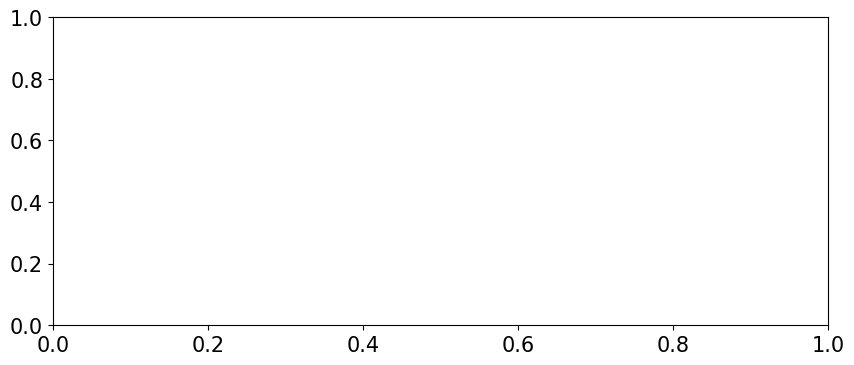

In [4]:
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(10,4))

for c, l, p in zip(casename,label, ocn_path):
  ds = xr.open_dataset(p+'{}_mon_ave_global_means.nc'.format(c)).sel(time=slice('0001-01-01',end_date))
  da =  weighted_temporal_mean(ds,'opottempmint')
  da.plot(ax=ax, label=l, lw=3)

#plt.suptitle(ds.opottempmint.attrs['long_name'])
ax.set_ylabel(ds.opottempmint.attrs['units'])
ax.set_xlabel('Year')
ax.grid()
ax.legend(ncol=3,loc=1);

In [ ]:
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(10,4))

for c, l, p in zip(casename,label, ocn_path):
  ds = xr.open_dataset(p+'{}_mon_ave_global_means.nc'.format(c)).sel(time=slice('0001-01-01',end_date))
  da =  weighted_temporal_mean(ds,'somint')  
  da.plot(ax=ax, label=l, lw=3)

#plt.suptitle(ds.somint.attrs['long_name'])
ax.set_ylabel(ds.somint.attrs['units'])
ax.set_xlabel('Year')
ax.grid()
ax.legend(ncol=3,loc=1);

### Globally-averaged T & S

In [ ]:
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(10,4))

for c, l, p in zip(casename,label, ocn_path):
  ds = xr.open_dataset(p+'{}_mon_ave_global_means.nc'.format(c)).sel(time=slice('0001-01-01',end_date))
  da =  weighted_temporal_mean(ds,'thetaoga') 
  da.plot(ax=ax, label=l, lw=3)

plt.title(ds.thetaoga.attrs['long_name'])
ax.set_ylabel(ds.thetaoga.attrs['units'])
ax.set_xlabel('Year')
ax.grid()
ax.legend(ncol=3,loc=0);

In [ ]:
fig, ax = plt.subplots()
for c, l, p in zip(casename,label, ocn_path):
  ds = xr.open_dataset(p+'{}_mon_ave_global_means.nc'.format(c)).sel(time=slice('0001-01-01',end_date))
  ds['soga'].plot(ax=ax, label=l, lw=3)
    
ax.set_title(ds.soga.attrs['long_name'])
ax.set_ylabel(ds.soga.attrs['units'])
ax.set_xlabel('Year')
ax.grid()
ax.legend();

In [ ]:
ocean_stats = []
for c, l, p in zip(casename,label, ocn_path):
  ds = xr.open_dataset(p+'{}_ocean.stats.nc'.format(c), decode_times=False)#.sel(time=slice('0001-01-01',end_date))
  stats_monthly = ds#.resample(time="1M", 
                    #           closed='left',
                    #           keep_attrs='True').mean('time', keep_attrs=True)
  ocean_stats.append(stats_monthly) 

### Truncations

In [ ]:
fig, ax = plt.subplots()
for i,l in zip(range(len(label)), label):
  ocean_stats[i].Truncs.plot(ax=ax,label=l,lw=3);
    
ax.legend()
ax.grid()

### Maximum finite-volume CFL

In [ ]:
fig, ax = plt.subplots()
for i,l in zip(range(len(label)), label):
  ocean_stats[i].max_CFL_trans.plot(ax=ax,label=l,lw=3);
    
ax.legend()
ax.grid();

### Maximum finite-difference CFL

In [ ]:
fig, ax = plt.subplots()
for i,l in zip(range(len(label)), label):
  ocean_stats[i].max_CFL_lin.plot(ax=ax,label=l,lw=3);
    
ax.legend()
ax.grid();

### Maximum CFL

In [ ]:
fig, ax = plt.subplots()
for i,l in zip(range(len(label)), label):
  ocean_stats[i].MaximumCFL.plot(ax=ax,label=l,lw=3);
    
ax.legend()
ax.grid();

### Energy/Mass

In [ ]:
fig, ax = plt.subplots()
for i,l in zip(range(len(label)), label):
  ocean_stats[i].EnergyMass.plot(ax=ax,label=l,lw=3);
    
ax.legend()
ax.grid();

### Mean Sea Level

In [ ]:
fig, ax = plt.subplots()
for i,l in zip(range(len(label)), label):
  ocean_stats[i].MeanSeaLevel.plot.line(ax=ax,label=l,lw=3);
    
ax.legend()
ax.grid();

### Total Mass

In [ ]:
fig, ax = plt.subplots()
for i,l in zip(range(len(label)), label):
  ocean_stats[i].TotalMass.plot(ax=ax,label=l,lw=3);
    
ax.legend()
ax.grid();

### Mean Salinity

In [ ]:
fig, ax = plt.subplots()
for i,l in zip(range(len(label)), label):
  ocean_stats[i].MeanSalin.plot(ax=ax,label=l,lw=3);
    
ax.legend()
ax.grid();

### Mean Temperature

In [ ]:
fig, ax = plt.subplots()
for i,l in zip(range(len(label)), label):
  ocean_stats[i].MeanTemp.plot(ax=ax,label=l,lw=3);
    
ax.legend()
ax.grid();

### Total Energy

In [ ]:
fig, ax = plt.subplots()
for i,l in zip(range(len(label)), label):
  ocean_stats[i].En.plot(ax=ax,label=l,lw=3);
    
ax.legend()
ax.grid();

### Available Potential Energy

In [ ]:
fig, ax = plt.subplots()
for i,l in zip(range(len(label)), label):
  ocean_stats[i].APE.sum(axis=1,
                      keep_attrs=True).plot(ax=ax,label=l,lw=3);
    
ax.legend()
ax.grid();

### Total Salt

In [ ]:
fig, ax = plt.subplots()
for i,l in zip(range(len(label)), label):
  ocean_stats[i].Salt.plot(ax=ax,label=l,lw=3);
    
ax.legend()
ax.grid();

### Total Salt Change between Entries

In [ ]:
fig, ax = plt.subplots()
for i,l in zip(range(len(label)), label):
  ocean_stats[i].Salt_chg.plot(ax=ax,label=l,lw=3);
    
ax.legend()
ax.grid();

### Anomalous Total Salt Change

In [ ]:
fig, ax = plt.subplots()
for i,l in zip(range(len(label)), label):
  ocean_stats[i].Salt_anom.plot(ax=ax,label=l,lw=3);
    
ax.legend()
ax.grid();

### Total Heat

In [ ]:
fig, ax = plt.subplots()
for i,l in zip(range(len(label)), label):
  ocean_stats[i].Heat.plot(ax=ax,label=l,lw=3);
    
ax.legend()
ax.grid();

### Total Heat Change between Entries

In [ ]:
fig, ax = plt.subplots()
for i,l in zip(range(len(label)), label):
  ocean_stats[i].Heat_chg.plot(ax=ax,label=l,lw=3);
    
ax.legend()
ax.grid();

### Anomalous Total Heat Change

In [ ]:
fig, ax = plt.subplots()
for i,l in zip(range(len(label)), label):
  ocean_stats[i].Heat_anom.plot(ax=ax,label=l,lw=3);
    
ax.legend()
ax.grid();

### Age

In [ ]:
fig, ax = plt.subplots()
for i,l in zip(range(len(label)), label):
  ocean_stats[i].age.plot(ax=ax,label=l,lw=3);
    
ax.legend()
ax.grid();